**Statistical Decision Theory**

1.Decision Frameworks

**Problem Formulation**



假設我們是一位量化投資人，在每個月月底必須決定下一個月的資產配置：全倉持有股票（Long）或是空倉持有現金（Cash）。

我們的目標是在獲取市場報酬的同時，盡可能規避熊市的資本損失。

根據統計決策理論（Statistical Decision Theory），我們將此問題定義如下：

Assigned Dataset (資料集):使用 yfinance API 擷取 0050.TW 過去十年的每日收盤價，並重採樣（Resample）計算出每月的實際報酬率（$R_t$）。

State of Nature ($\theta$):自然狀態代表市場下個月的真實表現，這在決策當下是未知的。為簡化模型，我們將下個月的市場狀態定義為二元集合 $\theta \in \{\theta_1, \theta_2\}$：$\theta_1$ (牛市/上漲)：下個月實際報酬率 $R > 0；$$\theta_2$ (熊市/下跌)：下個月實際報酬率 $R \le 0$

Action Space ($A$):投資人月底可以採取的決策行動空間定義為 $A = \{a_1, a_2\}$：$a_1$：持有股票 (Long Market)$a_2$：持有現金 (Hold Cash，假設無風險利率為 0)

Loss Function ($L(\theta, a)$):損失函數衡量在特定市場狀態下，採取特定行動所付出的代價。我們定義如下矩陣：$L(\theta_1, a_1) = 0$ （市場上漲且持有股票，決策正確）$L(\theta_2, a_2) = 0$ （市場下跌且持有現金，成功避險）$L(\theta_1, a_2) = R$ （市場上漲卻持有現金，損失為機會成本）$L(\theta_2, a_1) = |R|$ （市場下跌卻持有股票，損失為實際資本虧損）

數學表示式為：$$L(\theta, a) = \begin{cases} 0, & \text{if } (\theta=\theta_1, a=a_1) \text{ or } (\theta=\theta_2, a=a_2) \\ R, & \text{if } \theta=\theta_1, a=a_2 \\ -R, & \text{if } \theta=\theta_2, a=a_1 \end{cases}$$

/tmp/ipykernel_5746/816252146.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2016-01-01", end="2026-05-01", progress=False)


統計決策理論框架資料建構 (前 5 筆):


/tmp/ipykernel_5746/816252146.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = close_prices.resample('M').last()


,Actual_Return,State_of_Nature,Loss_if_a1_Long,Loss_if_a2_Cash
Date,,,,
2016-02-29,0.038136,Theta_1 (Bull),0.000000,0.038136
2016-03-31,0.055510,Theta_1 (Bull),0.000000,0.055510
2016-04-30,-0.047177,Theta_2 (Bear),0.047177,0.000000
2016-05-31,0.025162,Theta_1 (Bull),0.000000,0.025162
2016-06-30,0.036421,Theta_1 (Bull),0.000000,0.036421


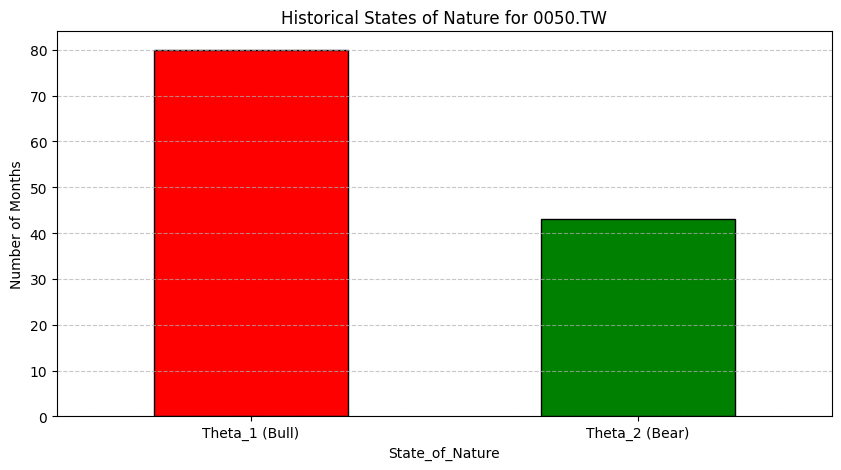

In [ ]:
# 安裝並載入所需套件 (若 Colab 環境尚未安裝 yfinance)
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 獲取 0050.TW 歷史資料
ticker = "0050.TW"
# 抓取過去約10年的資料
df = yf.download(ticker, start="2016-01-01", end="2026-05-01", progress=False)

# 2. 資料預處理：計算每月報酬率
# 將日資料重採樣為月底資料，使用還原收盤價 (Adj Close)
if isinstance(df.columns, pd.MultiIndex):
    close_prices = df['Close', ticker]
else:
    close_prices = df['Close']
monthly_data = close_prices.resample('M').last()
# 計算月報酬率
monthly_returns = monthly_data.pct_change().dropna()

# 3. 定義決策框架中的變數
decision_df = pd.DataFrame(monthly_returns)
decision_df.columns = ['Actual_Return']

# 定義 State of Nature (Theta)
# 預期報酬 > 0 為 Theta_1 (Bull)，否則為 Theta_2 (Bear)
decision_df['State_of_Nature'] = np.where(decision_df['Actual_Return'] > 0, 'Theta_1 (Bull)', 'Theta_2 (Bear)')

# 4. 模擬計算歷史狀態下的潛在 Loss Function
# 假設我們每個月都執行 a1 (Long) 或 a2 (Cash) 的潛在損失
decision_df['Loss_if_a1_Long'] = np.where(decision_df['Actual_Return'] <= 0, abs(decision_df['Actual_Return']), 0)
decision_df['Loss_if_a2_Cash'] = np.where(decision_df['Actual_Return'] > 0, decision_df['Actual_Return'], 0)

# 顯示前幾筆資料確認框架建構完成
print("統計決策理論框架資料建構 (前 5 筆):")
display(decision_df.head())

# 視覺化歷史的 State of Nature 分佈
plt.figure(figsize=(10, 5))
decision_df['State_of_Nature'].value_counts().plot(kind='bar', color=['red', 'green'], edgecolor='black')
plt.title(f'Historical States of Nature for {ticker}')
plt.ylabel('Number of Months')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Scenarios**

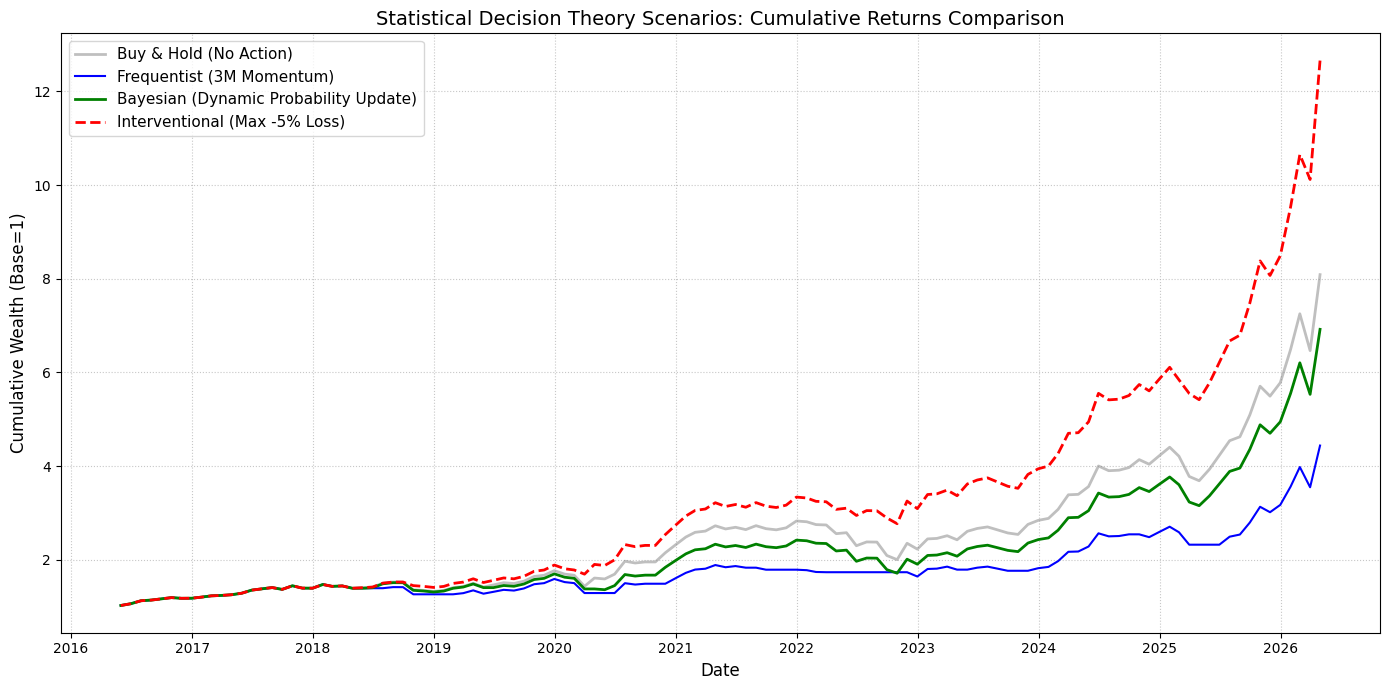

In [ ]:
# =========================================
# 第二題：Scenarios (三種情境視角實作與比較)
# =========================================
import numpy as np
import matplotlib.pyplot as plt

# 1. 頻率學派 (Frequentist): 滾動動能法則
# 計算過去 3 個月的累積報酬
decision_df['Rolling_3M_Ret'] = decision_df['Actual_Return'].rolling(3).sum().shift(1)
# 決策規則：動能為正選 a1(做多)，否則選 a2(現金)
decision_df['Freq_Action'] = np.where(decision_df['Rolling_3M_Ret'] > 0, 'a1', 'a2')
decision_df['Freq_Strategy_Return'] = np.where(decision_df['Freq_Action'] == 'a1', decision_df['Actual_Return'], 0)


# 2. 貝氏學派 (Bayesian): 動態後驗機率更新策略
bayes_action = []
confidence_threshold = 0.55 # 貝氏投資人的信心門檻：勝率需 > 55% 才做多

for i in range(len(decision_df)):
    # 前 24 個月作為建立初始信念(Prior)的觀察期，預設為持有
    if i < 24:
        bayes_action.append('a1')
        continue

    # 代理人只能看到 t 時刻之前的歷史資料
    history = decision_df.iloc[:i].copy()

    # 觀察上個月的狀態 (Evidence)
    last_month_return = history['Actual_Return'].iloc[-1]

    # 計算條件機率 (Posterior)
    if last_month_return < -0.03:
        # 尋找歷史中「前一個月也大跌 < -3%」的所有樣本
        cond_history = history[history['Actual_Return'].shift(1) < -0.03]
    else:
        # 尋找歷史中「前一個月平穩或上漲」的所有樣本
        cond_history = history[history['Actual_Return'].shift(1) >= -0.03]

    # 計算在該條件下，當月實際上漲(牛市)的機率
    if len(cond_history) > 0:
        posterior_prob = (cond_history['Actual_Return'] > 0).mean()
    else:
        posterior_prob = (history['Actual_Return'] > 0).mean() # 若無歷史樣本，退回先驗機率

    # 貝氏決策：後驗機率大於門檻則做多(a1)，否則抱現金(a2)
    if posterior_prob >= confidence_threshold:
        bayes_action.append('a1')
    else:
        bayes_action.append('a2')

decision_df['Bayes_Action'] = bayes_action
decision_df['Bayes_Strategy_Return'] = np.where(decision_df['Bayes_Action'] == 'a1', decision_df['Actual_Return'], 0)


# 3. 干預性視角 (Interventional): 反事實停損 (-5%)
# do(Limit Loss = -5%)
decision_df['Interventional_Return'] = np.where(decision_df['Actual_Return'] < -0.05, -0.05, decision_df['Actual_Return'])

# --- 計算累積報酬並視覺化比較 ---
# 去除 NaN 值以便計算累積報酬
plot_df = decision_df.dropna().copy()

# 計算累積資金曲線 (Cumulative Returns)
plot_df['Cum_Buy_Hold'] = (1 + plot_df['Actual_Return']).cumprod()
plot_df['Cum_Freq_Strategy'] = (1 + plot_df['Freq_Strategy_Return']).cumprod()
plot_df['Cum_Bayes_Strategy'] = (1 + plot_df['Bayes_Strategy_Return']).cumprod()
plot_df['Cum_Interventional'] = (1 + plot_df['Interventional_Return']).cumprod()

# 繪圖
plt.figure(figsize=(14, 7))
plt.plot(plot_df.index, plot_df['Cum_Buy_Hold'], label='Buy & Hold (No Action)', color='gray', alpha=0.5, linewidth=2)
plt.plot(plot_df.index, plot_df['Cum_Freq_Strategy'], label='Frequentist (3M Momentum)', color='blue', linewidth=1.5)
plt.plot(plot_df.index, plot_df['Cum_Bayes_Strategy'], label='Bayesian (Dynamic Probability Update)', color='green', linewidth=2)
plt.plot(plot_df.index, plot_df['Cum_Interventional'], label='Interventional (Max -5% Loss)', color='red', linestyle='--', linewidth=2)

plt.title('Statistical Decision Theory Scenarios: Cumulative Returns Comparison', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Wealth (Base=1)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

2.Estimation Problems

**Problem Formation**

假設我們是量化風險管理者，我們想回答：「明天台積電 (2330.TW) 的平均報酬與波動有多大？」我們從歷史資料反推產生報酬的母體分佈參數。

依估Estimation Theory我們將此問題定義如下：

**資料集**：使用 yfinance API 擷取 2330.TW 過去十年（2016-05-01 ~ 2026-05-01）的每日收盤價，計算對數報酬率 $\varepsilon_t = log(P_t / P_{t-1})$，得觀測序列 $i \equiv \{\varepsilon_s\}_{s=1}^{\bar t}$，$\bar t = $2433。

**State of Nature ($\theta$)**：母體分佈的真實參數，未知。假設報酬服從常態分佈：


$$
\varepsilon_t | \theta \sim(\mu,\sigma^{2})\; i.i.d,\qquad \theta = (\mu,\sigma^{2}) \in \mathbb R\times\mathbb R_{>0}.
$$


**Estimand ($q^{*}$)**：同時估計 $\mu$ 與 $\sigma$，故取整個參數：


$$
q^{*} \equiv \mathfrak q[F_Y^{*}] = (\mu,\,\sigma).
$$


**Action Space ($\hat q$)**：可提出的猜測 $\hat q = (\hat\mu,\hat\sigma) \in \mathbb R\times\mathbb R_{>0}$（連續二維）。


**Estimator**：把資料映到行動的規則 $es: i \mapsto \hat q = es(i)$。


**Estimative Loss (loss$(\theta,\hat q)$)**：採 squared Euclidean：


$$
\mathrm{loss}(\theta,\hat q) =
\begin{cases}
0, & \text{if } \hat q = q(\theta),\\[2pt]
\|q(\theta)-\hat q\|_{2}^{2} = (\mu-\hat\mu)^{2}+(\sigma-\hat\sigma)^{2}, & \text{otherwise}.
\end{cases}
$$

**Goal**：找出最小化期望損失的估計式
$$
es^{*} = \arg\min_{es}\mathbb E\!\left\{loss(\Theta,\,es(I))\right\}.
$$

---

In [ ]:
"""Estimation Theorem on TSMC (2330.TW): Frequentist / Bayesian / M-estimation."""
!pip install yfinance --quiet
import json, math, warnings
import numpy as np, pandas as pd, yfinance as yf
from scipy import stats
from scipy.optimize import minimize_scalar

TICKER, START, END = "2330.TW", "2016-05-01", "2026-05-01"

raw   = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
close = raw["Close"]
if isinstance(close, pd.DataFrame): close = close.iloc[:, 0]
log_ret = np.log(close / close.shift(1)).dropna().values # 對數報酬率 (會drop第一天數據)

n      = log_ret.size
y_bar  = log_ret.mean()
ssr    = ((log_ret - y_bar) ** 2).sum()      # sum(y_s - m)^2
s2     = ssr / (n - 1)                       # unbiased sample variance
s_bar  = math.sqrt(s2)

# Frequentist (MLE + Normal-based CIs)
# MLE
mu_freq    = y_bar
sigma_freq = math.sqrt(ssr / n)
# CI
z          = stats.norm.ppf(0.975) # 標準常態的 97.5% 分位數
mu_ci      = (y_bar - z*s_bar/math.sqrt(n), y_bar + z*s_bar/math.sqrt(n))
chi_lo, chi_hi = stats.chi2.ppf([0.025, 0.975], df=n-1)
sig_ci     = (math.sqrt((n-1)*s2/chi_hi), math.sqrt((n-1)*s2/chi_lo))

# Bayesian Normal-Inverse-Gamma conjugate
# Initial parameters
mu0, kappa0, alpha0, beta0 = 0.0, 1.0, 2.0, 1e-4
# Update
kappa_n = kappa0 + n
mu_n    = (kappa0*mu0 + n*y_bar) / kappa_n
alpha_n = alpha0 + n/2
beta_n  = beta0 + 0.5*ssr + 0.5*kappa0*n*(y_bar-mu0)**2/kappa_n

post_mu    = mu_n
post_sigma = math.sqrt(beta_n / (alpha_n - 1))
df_t, scale_t = 2*alpha_n, math.sqrt(beta_n / (alpha_n*kappa_n))
# marginal -> CI
mu_cred    = stats.t.interval(0.95, df=df_t, loc=mu_n, scale=scale_t)
sig_cred   = tuple(math.sqrt(stats.invgamma.ppf(q, a=alpha_n, scale=beta_n))
                   for q in (0.025, 0.975))
gamma_mu   = kappa0 / kappa_n

# 3. M-estimation: Huber loss with MAD scale
# Huber Loss (For heavy tail)
def huber_rho(u, k):
    a = np.abs(u)
    return np.where(a <= k, 0.5*u*u, k*a - 0.5*k*k)

med       = np.median(log_ret)
sigma_mad = 1.4826 * np.median(np.abs(log_ret - med)) # 1.4826 = 1/ (75% quantile of standard normal)
k_hub     = 1.345 * sigma_mad
# Minimizing loss
mu_hub    = minimize_scalar(lambda m: huber_rho(log_ret-m, k_hub).mean(),
                            bracket=(med-5*sigma_mad, med+5*sigma_mad)).x
sigma_hub = 1.4826 * np.median(np.abs(log_ret - mu_hub))

# output
print(f"n = {n}   sample mean = {y_bar:+.4e}   sample sd = {s_bar:.4e}\n")
rows = [("Frequentist",   mu_freq,  sigma_freq),
        ("Bayesian",      post_mu,  post_sigma),
        ("M-est (Huber)", mu_hub,   sigma_hub)]
print(f"{'Framework':<14} | {'μ̂ daily':>12} | {'σ̂ daily':>10} | {'μ̂ ann.':>9} | {'σ̂ ann.':>9}")
print("-"*68)
for name, m, s in rows:
    print(f"{name:<14} | {m:>+12.4e} | {s:>10.4e} | {m*252:>+8.2%} | {s*math.sqrt(252):>8.2%}")

print(f"\nFreq 95% CI : μ ∈ [{mu_ci[0]:+.3e}, {mu_ci[1]:+.3e}],  σ ∈ [{sig_ci[0]:.3e}, {sig_ci[1]:.3e}]")
print(f"Bayes CrI   : μ ∈ [{mu_cred[0]:+.3e}, {mu_cred[1]:+.3e}], σ ∈ [{sig_cred[0]:.3e}, {sig_cred[1]:.3e}]")
print(f"shrinkage γ_μ = {gamma_mu:.3e}    Huber k = {k_hub:.3e}")

results = {
    "ticker": TICKER, "period": f"{START} ~ {END}", "n_obs": int(n),
    "frequentist": {"mu_hat": float(mu_freq), "sigma_hat": float(sigma_freq),
                    "mu_95CI": list(map(float, mu_ci)), "sigma_95CI": list(map(float, sig_ci))},
    "bayesian":    {"prior": {"mu0": mu0, "kappa0": kappa0, "alpha0": alpha0, "beta0": beta0},
                    "post_mean_mu": float(post_mu), "post_mean_sigma": float(post_sigma),
                    "mu_95CrI": list(map(float, mu_cred)), "sigma_95CrI": list(map(float, sig_cred)),
                    "shrinkage_gamma_mu": float(gamma_mu),
                    "post_hyper": {"mu_n": float(mu_n), "kappa_n": float(kappa_n),
                                   "alpha_n": float(alpha_n), "beta_n": float(beta_n)}},
    "m_estimation":{"huber_k": float(k_hub), "mu_hat": float(mu_hub), "sigma_hat": float(sigma_hub)},
}
with open("estimation_2330TW_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

n = 2429   sample mean = +1.2150e-03   sample sd = 1.7109e-02

Framework      |     μ̂ daily |   σ̂ daily |   μ̂ ann. |   σ̂ ann.
--------------------------------------------------------------------
Frequentist    |  +1.2150e-03 | 1.7106e-02 |  +30.62% |   27.15%
Bayesian       |  +1.2145e-03 | 1.7101e-02 |  +30.61% |   27.15%
M-est (Huber)  |  +1.0751e-03 | 1.4169e-02 |  +27.09% |   22.49%

Freq 95% CI : μ ∈ [+5.346e-04, +1.895e-03],  σ ∈ [1.664e-02, 1.760e-02]
Bayes CrI   : μ ∈ [+5.345e-04, +1.895e-03], σ ∈ [1.663e-02, 1.759e-02]
shrinkage γ_μ = 4.115e-04    Huber k = 1.898e-02


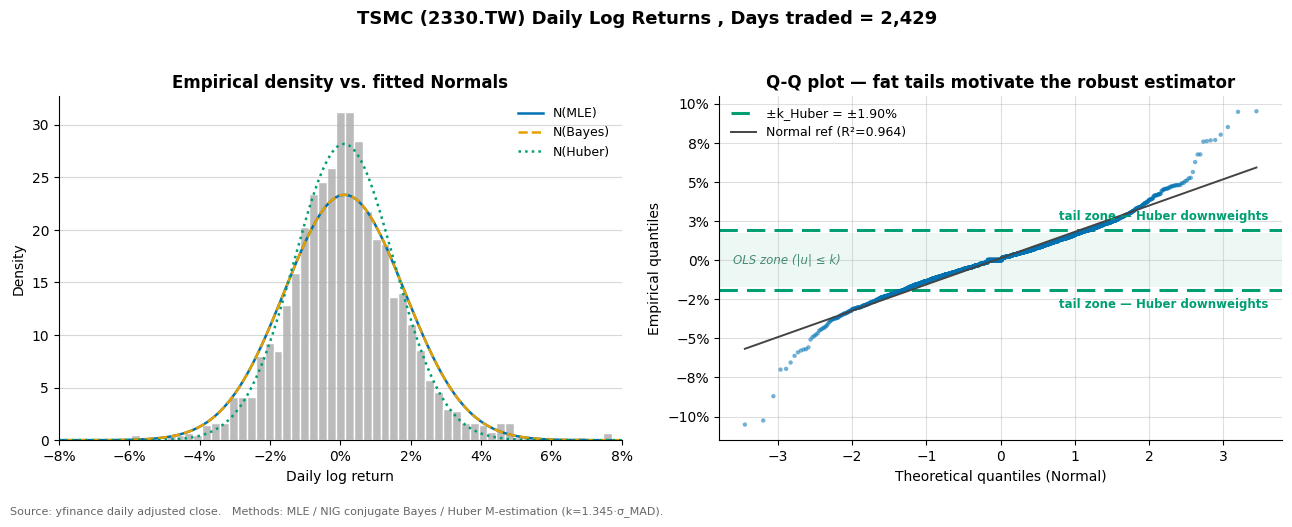

In [ ]:
import matplotlib.pyplot as plt, matplotlib.ticker as mtick

C_FREQ, C_BAYES, C_HUBER, C_HIST = "#0072B2", "#E69F00", "#009E73", "#BBBBBB"
plt.rcParams.update({"font.size": 10, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})

fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle(f"TSMC ({TICKER}) Daily Log Returns , Days traded = {n:,}",
             fontsize=13, fontweight="bold")

# B. Histogram + fitted Normals
bins = np.linspace(log_ret.min(), log_ret.max(), 80)
ax[0].hist(log_ret, bins=bins, density=True, color=C_HIST, edgecolor="white", lw=0.4)
xs = np.linspace(log_ret.min(), log_ret.max(), 600)
ax[0].plot(xs, stats.norm.pdf(xs, mu_freq, sigma_freq), color=C_FREQ,  lw=1.8, label="N(MLE)")
ax[0].plot(xs, stats.norm.pdf(xs, post_mu, post_sigma), color=C_BAYES, lw=1.8, ls="--", label="N(Bayes)")
ax[0].plot(xs, stats.norm.pdf(xs, mu_hub,  sigma_hub),  color=C_HUBER, lw=1.8, ls=":",  label="N(Huber)")
ax[0].set_xlim(-0.08, 0.08)
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax[0].set_xlabel("Daily log return"); ax[0].set_ylabel("Density")
ax[0].set_title("Empirical density vs. fitted Normals")
ax[0].legend(frameon=False, fontsize=9); ax[0].grid(axis="y", alpha=0.5)

# C. Q-Q plot — Huber threshold made prominent
(osm, osr), (slope, intercept, r) = stats.probplot(log_ret, dist="norm")

# soft shaded "OLS zone" between ±k_Huber, so the boundary jumps out
ax[1].axhspan(-k_hub, k_hub, color=C_HUBER, alpha=0.07, zorder=0)

# the threshold lines themselves: thicker, dashed (not dotted), with a subtle halo
for sign in (+1, -1):
    ax[1].axhline(sign*k_hub, color="white",   lw=4.5, zorder=1)          # halo
    ax[1].axhline(sign*k_hub, color=C_HUBER,   lw=2.2, ls=(0,(6,3)),      # main dashed line
                  zorder=2,
                  label=f"±k_Huber = ±{k_hub*100:.2f}%" if sign == +1 else None)

# scatter + reference line on top
ax[1].scatter(osm, osr, s=10, color=C_FREQ, alpha=0.55, edgecolor="none", zorder=3)
ax[1].plot(osm, slope*osm + intercept, color="#444", lw=1.4,
           label=f"Normal ref (R²={r**2:.3f})", zorder=3)

# label the two zones directly on the chart
xlim = ax[1].get_xlim()
ax[1].text(xlim[1]*0.95,  k_hub + 0.005, "tail zone — Huber downweights",
           color=C_HUBER, fontsize=8.5, ha="right", va="bottom", fontweight="bold")
ax[1].text(xlim[1]*0.95, -k_hub - 0.005, "tail zone — Huber downweights",
           color=C_HUBER, fontsize=8.5, ha="right", va="top", fontweight="bold")
ax[1].text(xlim[0]*0.95, 0, "OLS zone (|u| ≤ k)",
           color="#2a7a5b", fontsize=8.5, ha="left", va="center",
           style="italic", alpha=0.85)

ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax[1].set_xlabel("Theoretical quantiles (Normal)"); ax[1].set_ylabel("Empirical quantiles")
ax[1].set_title("Q-Q plot — fat tails motivate the robust estimator")
ax[1].legend(frameon=False, fontsize=9, loc="upper left")
ax[1].grid(alpha=0.4)

fig.text(0.01, 0.01, "Source: yfinance daily adjusted close.   Methods: MLE / NIG conjugate Bayes / Huber M-estimation (k=1.345·σ_MAD).",
         fontsize=8, color="#666")
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.savefig("estimation_panels_BC_2330TW.png", dpi=150, bbox_inches="tight")
plt.show()

圖表解讀

**經驗分配 vs. 三條常態擬合**

灰色直方圖在零附近的高峰明顯中間高峰且heavy tail。三條擬合常態裡，Huber（綠虛線）的峰最接近真實峰值，因為它的 σ̂ = 1.42% 比 MLE 的 1.71% 小；代價是它的尾巴明顯不夠胖，無法描述 ±4% 以外的觀測。MLE（藍實線）與 Bayesian（橘虛線）兩條曲線幾乎完全重疊，視覺上印證了表中 μ̂_MLE = 0.1215% 與 E[μ|i] = 0.1215% 幾乎完全一致。


**Q-Q plot**

在 *OLS zone*（綠色淺底，|u| ≤ k_Huber = 1.90%）以內，資料貼合得相當好；一旦點跨過 ±k_Huber 進入 *tail zone*，便明顯沿 S 形偏離參考線。R² = 0.964 看起來很高，但那只是被中央資料量主導的指標。

**結論**

Heavy tail 把 MLE σ̂ 撐高了 17%（年化 27.15% vs. Huber 的 22.49%），μ̂ 也被高頻次的極端正報酬向上拉了 11%（年化 30.62% vs. 27.09%）。

MLE/Bayesian 衡量「包含所有極端日子的平均離散程度」。做 VaR、選擇權定價或壓力測試時 MLE 比較合適

Huber/MAD 衡量「典型一天的離散程度」。描述「日常波動感」時 Huber 更貼近直覺。

###3. Risk Decomposition

MSE Decomposition: Prove that the risk of an estimator decomposes into squared bias and variance

**Claim**: $\mathfrak{r}(es) = bias^2(es) + var(es)$.

Let $es$ be an estimator of an unknown parameter $\theta \in \mathbb{R}$. Write $\mu := \mathbb{E}[es]$

Define

$$
\mathfrak{r}(es) \;:=\; \mathbb{E}\!\left[(es - \theta)^2\right], \qquad
bias(es) \;:=\; \mu - \theta, \qquad
var(es) \;:=\; \mathbb{E}\!\left[(es - \mu)^2\right].
$$

**Proof.**

$$
\mathfrak{r}(es) \;=\; \mathbb{E}\!\left[(es - \theta)^2\right]
\;=\; \mathbb{E}\!\left[\big((es - \mu) + (\mu - \theta)\big)^2\right] \;=\; \mathbb{E}\!\left[(es-\mu)^2\right]
\;+\; 2\,\mathbb{E}\!\left[(es-\mu)(\mu - \theta)\right]
\;+\; \mathbb{E}\!\left[(\mu - \theta)^2\right].
$$

So,
$$
\mathfrak{r}(es) \;=\; var(es) + 2(\mu - \theta)(\mu - \mu) + bias^2(es)
\;=\; var(es) + bias^2(es)
$$

Thus, proof

---

Excess Risk Decomposition: Derive the decomposition of excess risk into approximation and estimation errors

**Claim**: $\varrho^{xs}(es^M_{\mathscr{H}}) = \varrho^{app}_{\mathscr{H}} + \varrho^{est}(es^M_{\mathscr{H}})$.

For any function $f$, define the population risk

$$
\varrho(f) \;:=\; \mathbb{E}_{(X,Y)\sim\mathscr{D}}[L(f(X),\,Y)].
$$

We know that:

$$
\varrho^{*} \;:=\; \inf_{f}\varrho(f)
$$

$$
\varrho^{*}_{\mathscr{H}} \;:=\; \inf_{f \in \mathscr{H}}\, \varrho(f)
$$

$$
es^M_{\mathscr{H}} \;:=\; \arg\min_{f \in \mathscr{H}}\, \frac{1}{M}\sum_{s=1}^{M} L(f(X_s),\,Y_s)
$$

The three defined quantities are

$$
\varrho^{xs}(es^M_{\mathscr{H}}) \;:=\; \varrho(es^M_{\mathscr{H}}) - \varrho^{*}, \quad\text{(excess risk)}
$$

$$
\varrho^{app}_{\mathscr{H}} \;:=\; \varrho^{*}_{\mathscr{H}} - \varrho^{*}, \quad\text{(approximation error)}
$$

$$
\varrho^{est}(es^M_{\mathscr{H}}) \;:=\; \varrho(es^M_{\mathscr{H}}) - \varrho^{*}_{\mathscr{H}}, , \quad\text{(estimation error)}
$$

**Proof.**

$$
\varrho^{\mathrm{xs}}(es^M_{\mathscr{H}})
\;=\; \varrho(es^M_{\mathscr{H}}) - \varrho^{*}
\;=\; \underbrace{\big[\varrho(es^M_{\mathscr{H}}) - \varrho^{*}_{\mathscr{H}}\big]}
\;+\; \underbrace{\big[\varrho^{*}_{\mathscr{H}} - \varrho^{*}\big]}
\;=\; \varrho^{app}_{\mathscr{H}} \;+\; \varrho^{est}(es^M_{\mathscr{H}})
$$

Thus, proof.

4.The Black-Litterman Model

**Comparative Analysis: Classical vs. Probabilistic Inference Approaches**




### 1. 傳統的貝氏推論模型 (Classical Parametric / Bayesian Inference)
* **核心假設：** 強烈依賴資產報酬服從**常態分配 (Normal Distribution)** 或對數常態分配的參數化假設。
* **推論機制：** 將市場隱含的預期報酬視為先驗分配（Prior），投資人的觀點視為概似函數（Likelihood）。透過共軛先驗（Conjugate Prior）的數學性質，貝氏更新會直接計算出一個**「全新的期望值向量 $\mu$ 與共變異數矩陣 $\Sigma$」**。
* **限制：** 此方法會直接改寫資料的生成過程（Data-generating process）。此外，它很難處理非常態特徵（如波動度飆升、尾部風險、偏態），且主觀觀點通常只能侷限於線性預期報酬。

### 2. 基於最小相對熵的機率推論 (Probabilistic Inference via Minimum Relative Entropy)
* **核心假設：** 採用**無母數（Non-parametric）**的經驗分配。我們不需要假設常態分配，而是直接使用由歷史數據構成的「情境矩陣（Scenario Matrix）」，並賦予每個情境一個初始的相等機率 $\bar{p}_t = 1/\bar{t}$。
* **推論機制：** 當投資人引入主觀觀點（例如：某資產的波動率大於 $12\%$），我們**完全不改變歷史情境的數值 $x_t$ 本身**。相反地，我們透過最小化**相對熵 (Kullback-Leibler Divergence)**，去尋找一組新的情境機率權重 $p_t$。
* **數學表達：** 我們尋求新的機率向量 $p$，以最小化相對熵：
  $$\min_{p} \sum_{t=1}^{\bar{t}} p_t \ln\left(\frac{p_t}{\bar{p}_t}\right)$$
  同時滿足觀點的限制式（例如 $\sum p_t x_t = \text{View}$）與機率公理（$\sum p_t = 1$）。
* **優勢：** 這種方法能優雅地將複雜的觀點（如壓力測試、非線性選擇權觀點）融合進模型中。它強制整體分配遵守新規則，同時物理上盡可能減少對原始市場基準（Baseline）的偏離，完美保留了資產間原有的非線性關聯結構。

---
**實作驗證：最小相對熵 (Entropy Pooling) 概念展示**
以下程式碼模擬了一個包含 10 個歷史情境的資產。在先驗（Prior）狀態下，每個情境發生的機率皆為均等的 10%。當我們注入一個「預期報酬需達到 8%」的主觀觀點後，觀察機率推論演算法如何「重新分配機率權重」而不更動原始歷史報酬資料。

【先驗狀態 (Prior)】
先驗機率分佈: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
先驗預期報酬: 3.80%

【後驗狀態 (Posterior) - 融合觀點後】
後驗機率分佈: [0.0453 0.0561 0.0646 0.0745 0.0859 0.0922 0.1062 0.1225 0.1515 0.2013]
後驗預期報酬: 6.50%



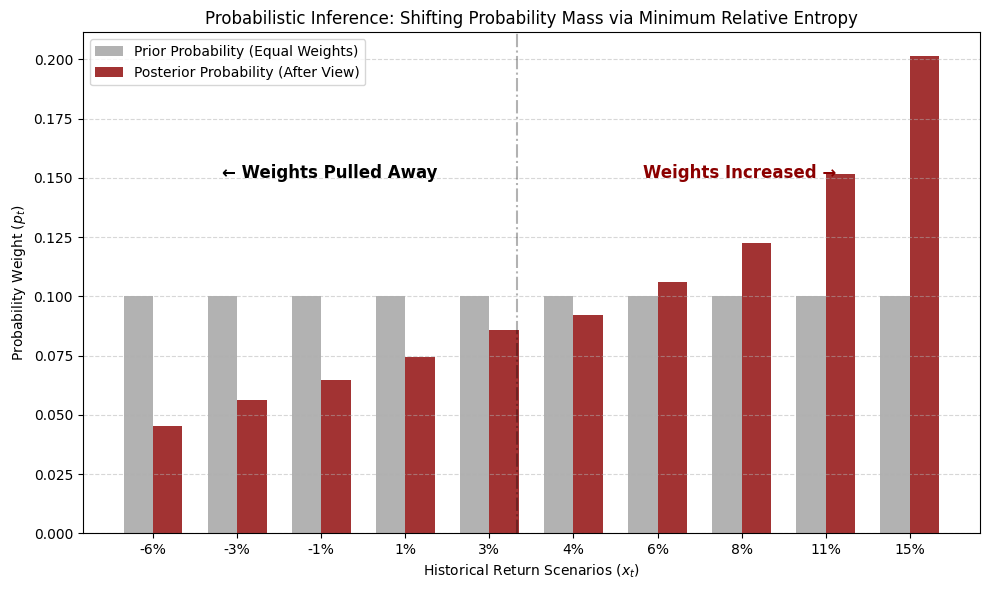

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. 建構歷史情境矩陣 (Historical Scenario Matrix)
# 假設我們有 10 個歷史觀測到的月報酬率情境
returns_scenario = np.array([-0.06, -0.03, -0.01, 0.01, 0.03, 0.04, 0.06, 0.08, 0.11, 0.15])
N_scenarios = len(returns_scenario)

# 2. 定義先驗機率 (Prior Probability)
# 在沒有觀點時，我們假設每個歷史情境發生的機率是均等的 (1/N)
p_prior = np.ones(N_scenarios) / N_scenarios
prior_mean_return = np.sum(p_prior * returns_scenario)

print(f"【先驗狀態 (Prior)】")
print(f"先驗機率分佈: {p_prior}")
print(f"先驗預期報酬: {prior_mean_return:.2%}\n")

# 3. 注入主觀觀點 (Subjective View)
# 投資人觀點：預期未來的平均報酬率會上升至 6.5% (Probabilistic Inference)
view_target_mean = 0.065

# 4. 最小相對熵最佳化 (Minimum Relative Entropy Optimization)
# 目標函數：計算 KL Divergence (相對熵)
def kl_divergence(p, prior_p):
    # 加上微小值 1e-10 避免 log(0) 的錯誤
    return np.sum(p * np.log((p + 1e-10) / (prior_p + 1e-10)))

# 限制條件 (Constraints)
constraints = (
    {'type': 'eq', 'fun': lambda p: np.sum(p) - 1.0}, # 機率總和必須為 1
    {'type': 'eq', 'fun': lambda p: np.sum(p * returns_scenario) - view_target_mean} # 新的預期報酬必須滿足觀點
)

# 變數邊界 (Bounds)：每個情境的機率必須介於 0 到 1 之間
bounds = [(1e-5, 1.0) for _ in range(N_scenarios)]

# 執行最佳化求解
initial_guess = p_prior.copy()
result = minimize(kl_divergence, initial_guess, args=(p_prior,),
                  method='SLSQP', bounds=bounds, constraints=constraints)

p_posterior = result.x
posterior_mean_return = np.sum(p_posterior * returns_scenario)

print(f"【後驗狀態 (Posterior) - 融合觀點後】")
print(f"後驗機率分佈: {np.round(p_posterior, 4)}")
print(f"後驗預期報酬: {posterior_mean_return:.2%}\n")

# 5. 視覺化機率權重的轉移 (Visualization)
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(N_scenarios)

plt.bar(index, p_prior, bar_width, label='Prior Probability (Equal Weights)', color='gray', alpha=0.6)
plt.bar(index + bar_width, p_posterior, bar_width, label='Posterior Probability (After View)', color='darkred', alpha=0.8)

# 在 X 軸標示該情境的實際報酬率
plt.xticks(index + bar_width / 2, [f"{r:.0%}" for r in returns_scenario])
plt.xlabel('Historical Return Scenarios ($x_t$)')
plt.ylabel('Probability Weight ($p_t$)')
plt.title('Probabilistic Inference: Shifting Probability Mass via Minimum Relative Entropy')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 標示出哪邊的機率被抽離，哪邊被加重
plt.axvline(x=4.5, color='black', linestyle='-.', alpha=0.3)
plt.text(1, 0.15, '← Weights Pulled Away', color='black', fontsize=12, fontweight='bold')
plt.text(6, 0.15, 'Weights Increased →', color='darkred', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

由上述 Python 實作與圖表可知，傳統 BL 模型透過精確度加權來修改常態分配的參數 $(\mu, \Sigma)$，這會改變資料的生成過程；相反地，Probabilistic Inference (Entropy Pooling) 在融合主觀觀點時，完全保留了原始歷史情境的數值不變，僅透過最小化相對熵來轉移「機率權重 ($p_t$)」。這種數學意涵使得後驗分配能夠在滿足投資人觀點的同時，完美保留市場原本的非線性特徵（如肥尾效應）。